In [1]:
import numpy as np
# นำเข้าไลบรารี NumPy เพื่อจัดการกับข้อมูลตัวเลขและอาเรย์
import pandas as pd
# นำเข้าไลบรารี pandas สำหรับจัดการข้อมูลในรูปแบบ DataFrame (ตาราง)
import matplotlib.pyplot as plt
# นำเข้า matplotlib (โมดูลย่อย pyplot) สำหรับสร้างกราฟข้อมูล
from sklearn.linear_model import LinearRegression
# นำเข้า LinearRegression จาก scikit-learn สำหรับสร้างโมเดลถดถอยเชิงเส้น

np.random.seed(42)
# กำหนดค่า seed เพื่อให้การสุ่มข้อมูลทุกครั้งได้ผลลัพธ์เหมือนกัน (เพื่อให้ผลลัพธ์ที่คาดหมาย reproducible)
n = 50
# จำนวนตัวอย่างข้อมูล (เช่น จำลองข้อมูลนักเรียน 50 คน)
# สร้างข้อมูลตัวแปรอิสระ X (ชั่วโมงการอ่านหนังสือ) แบบสุ่มในช่วง 0 ถึง 12 ชั่วโมง
X = np.random.rand(n) * 12
# สร้างความคลาดเคลื่อนแบบสุ่ม (noise) จากการแจกแจงปกติ (ค่าเฉลี่ย 0 ส่วนเบี่ยงเบนมาตรฐาน 5) เพื่อสะท้อนปัจจัยอื่นๆ ที่มีผลต่อคะแนน
noise = np.random.normal(0, 5, n)
# คำนวณค่าตัวแปรตาม Y (คะแนนสอบ) ตามสมการที่กำหนด: คะแนนพื้นฐาน 30 บวกกับ 5 เท่าของชั่วโมงที่อ่านหนังสือ และบวก noise ที่สร้างไว้
Y = 30 + 5 * X + noise

# สร้าง DataFrame จากข้อมูลที่ได้เพื่อให้ง่ายต่อการดูและจัดการข้อมูล
df = pd.DataFrame({'Hours': X,
# Hours = ชั่วโมงการอ่านหนังสือ (ตัวแปรอิสระ X)
                   'Score': Y})
                   # Score = คะแนนสอบ (ตัวแปรตาม Y)
print("ตัวอย่างข้อมูล 5 แถวแรก:")
print(df.head())  # แสดงข้อมูล 5 แถวแรกของตารางข้อมูลที่สร้างขึ้น

ตัวอย่างข้อมูล 5 แถวแรก:
       Hours      Score
0   4.494481  56.164740
1  11.408572  87.899700
2   8.783927  73.341395
3   7.183902  64.413991
4   1.872224  31.968508


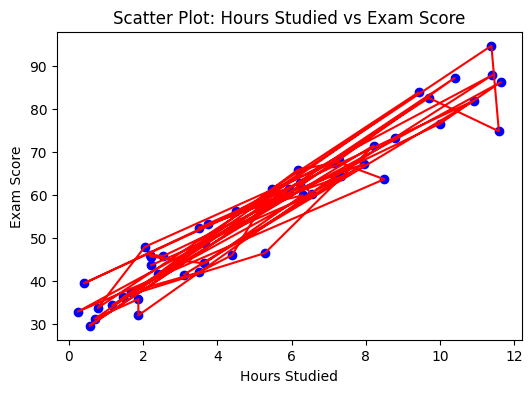

In [6]:
# สร้างกราฟการกระจาย (Scatter Plot) แสดงความสัมพันธ์ระหว่าง Hours กับ Score
plt.figure(figsize=(6,4))
plt.scatter(df['Hours'], df['Score'], color='blue', label='Data Points')
plt.plot(df['Hours'], df['Score'], color='red', label='Best Fit Line')
plt.xlabel('Hours Studied')    # ป้ายแกน X (ชั่วโมงที่อ่านหนังสือ)
plt.ylabel('Exam Score')       # ป้ายแกน Y (คะแนนสอบ)
plt.title('Scatter Plot: Hours Studied vs Exam Score')
plt.show()

In [3]:
# เตรียมข้อมูล X และ y สำหรับโมเดล
X_data = df[['Hours']]
# เลือกคอลัมน์ Hours มาเป็น DataFrame 2 มิติ (เพื่อใช้เป็นคุณสมบัติ X ในโมเดล)
y_data = df['Score']
# เลือกคอลัมน์ Score มาเป็นชุดคำตอบ (y)

model = LinearRegression()
# สร้างตัวแบบ Linear Regression
model.fit(X_data, y_data)
# ฝึกโมเดลกับข้อมูล (fit หาเส้นที่เหมาะสมที่สุดจากข้อมูลที่มี)
# แสดงค่าความชันและจุดตัดแกนที่โมเดลได้เรียนรู้มา
print("Coefficient (b1) หรือความชันของเส้น:", model.coef_[0])
print("Intercept (b0) หรือจุดตัดแกน Y:", model.intercept_)

Coefficient (b1) หรือความชันของเส้น: 4.906902501605461
Intercept (b0) หรือจุดตัดแกน Y: 30.483446372344428


In [4]:
r_squared = model.score(X_data, y_data)
print("R-squared ของโมเดล (ประสิทธิภาพการอธิบายความแปรปรวนของข้อมูล):", r_squared)

R-squared ของโมเดล (ประสิทธิภาพการอธิบายความแปรปรวนของข้อมูล): 0.9323441094220372


คาดการณ์คะแนนสอบสำหรับการอ่าน 8 ชั่วโมง = 69.74 คะแนน


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


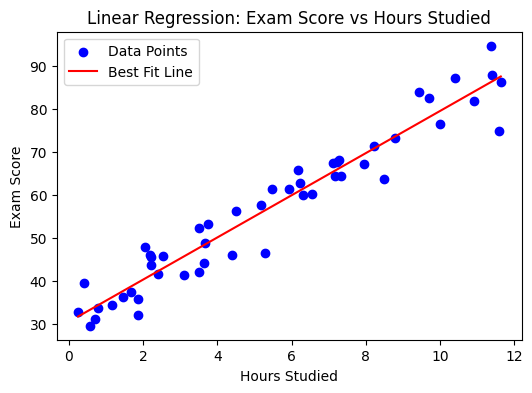

In [5]:
# ใช้โมเดลทำนายคะแนนสอบของนักเรียนที่อ่านหนังสือ 8 ชั่วโมง (ตัวอย่างใหม่)
hours_new = np.array([[8]])
# สร้างอาเรย์ 2 มิติ [[8]] เป็นจำนวนชั่วโมงใหม่
predicted_score = model.predict(hours_new)
print(f"คาดการณ์คะแนนสอบสำหรับการอ่าน {hours_new[0][0]} ชั่วโมง = {predicted_score[0]:.2f} คะแนน")

# สร้างกราฟแสดงจุดข้อมูลจริงและเส้นถดถอยเชิงเส้นที่ได้จากโมเดล
line_x = np.linspace(df['Hours'].min(), df['Hours'].max(), 100)
# สร้างช่วงค่า X ตั้งแต่ min ถึง max
line_y = model.predict(line_x.reshape(-1, 1))
# คำนวณค่าทำนายตามเส้นตรงสำหรับค่า X ทุกจุดในช่วง

plt.figure(figsize=(6,4))
plt.scatter(df['Hours'], df['Score'], color='blue', label='Data Points')
# จุดข้อมูลจริง (สีน้ำเงิน)
plt.plot(line_x, line_y, color='red', label='Best Fit Line')
# เส้นตรงที่โมเดลเรียนรู้มา (สีแดง)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Exam Score vs Hours Studied')
plt.legend()
plt.show()

In [10]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/DataScience/Datasets/bdims.csv')

In [11]:
df = df[['sex', 'age', 'wgt', 'hgt', 'hip_gi', 'wai_gi']]
df.columns = ['sex','age', 'weight', 'height', 'hip', 'waist']
df.columns

Index(['sex', 'age', 'weight', 'height', 'hip', 'waist'], dtype='object')

In [12]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     507 non-null    int64  
 1   age     507 non-null    int64  
 2   weight  507 non-null    float64
 3   height  507 non-null    float64
 4   hip     507 non-null    float64
 5   waist   507 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 23.9 KB


In [13]:
df.isnull().sum()

,0
sex,0
age,0
weight,0
height,0
hip,0
waist,0


In [14]:
df.describe()

,sex,age,weight,height,hip,waist
count,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000
mean,0.487179,30.181460,69.147535,171.143787,96.680868,76.979487
std,0.500329,9.608472,13.345762,9.407205,6.680623,11.012688
min,0.000000,18.000000,42.000000,147.200000,78.800000,57.900000
25%,0.000000,23.000000,58.400000,163.800000,92.000000,68.000000
50%,0.000000,27.000000,68.200000,170.300000,96.000000,75.800000
75%,1.000000,36.000000,78.850000,177.800000,101.000000,84.500000
max,1.000000,67.000000,116.400000,198.100000,128.300000,113.200000


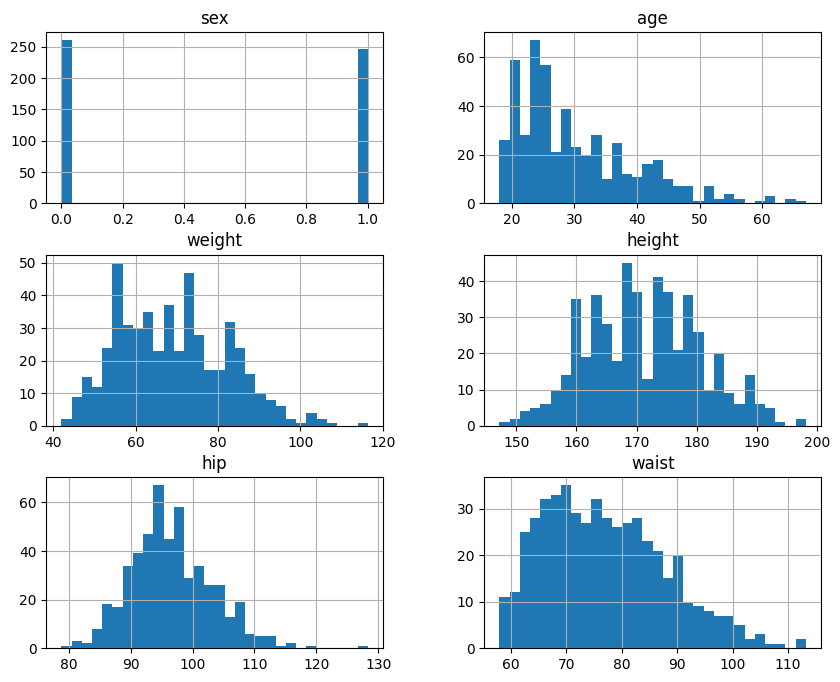

In [15]:
import matplotlib.pyplot as plt
df.hist(bins=30, figsize=(10,8))
plt.show()

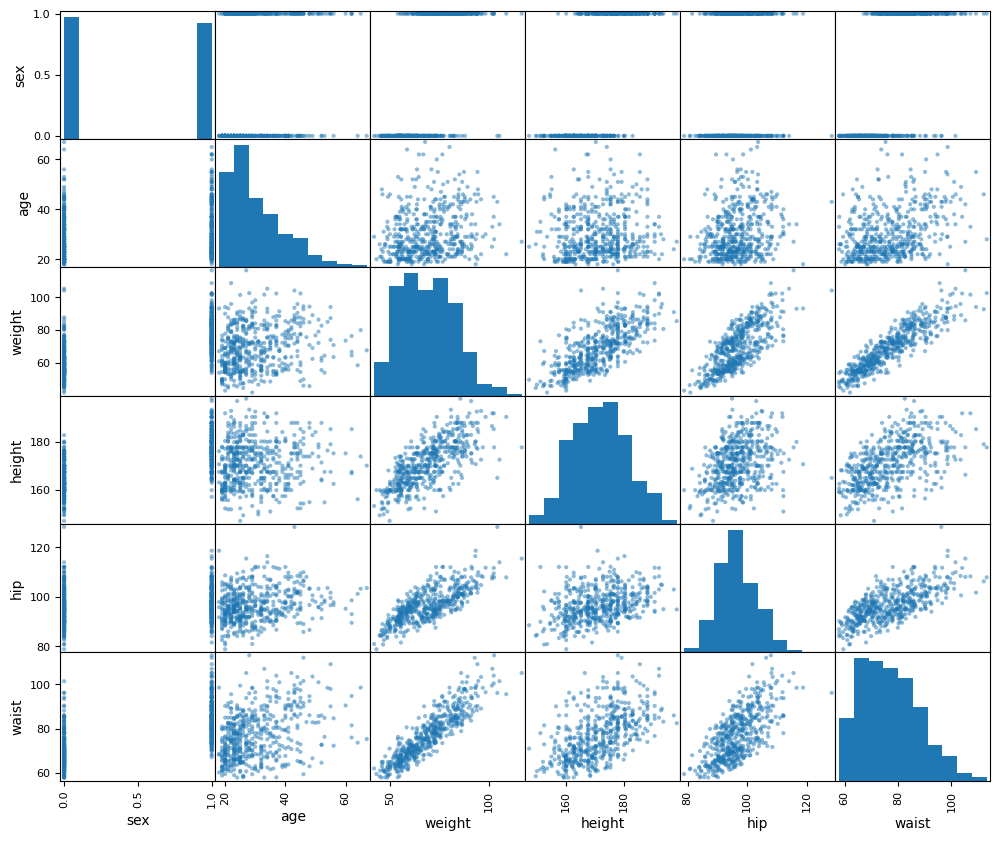

In [16]:
from pandas.plotting import scatter_matrix
scatter_matrix(df, figsize=(12,10))
plt.show()

In [17]:
corr_matrix = df.corr()
corr_matrix

,sex,age,weight,height,hip,waist
sex,1.000000,0.150945,0.657726,0.684662,0.158058,0.669203
age,0.150945,1.000000,0.207265,0.067883,0.227080,0.369131
weight,0.657726,0.207265,1.000000,0.717301,0.762969,0.903991
height,0.684662,0.067883,0.717301,1.000000,0.338584,0.552960
hip,0.158058,0.227080,0.762969,0.338584,1.000000,0.692351
waist,0.669203,0.369131,0.903991,0.552960,0.692351,1.000000


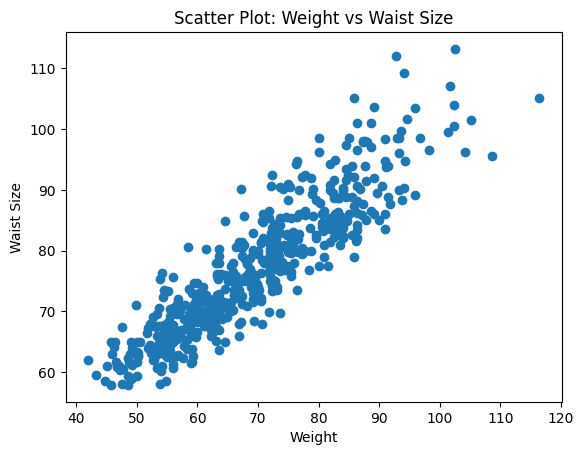

In [18]:
plt.scatter(df['weight'], df['waist'])
plt.xlabel('Weight')
plt.ylabel('Waist Size')
plt.title('Scatter Plot: Weight vs Waist Size')
plt.show()

In [19]:
df['bmi'] = df['weight'] / (df['height']/100)**2
df.head()

,sex,age,weight,height,hip,waist,bmi
0,1,21,65.6,174.0,93.5,71.5,21.667327
1,1,23,71.8,175.3,94.8,79.0,23.364722
2,1,28,80.7,193.5,95.0,83.2,21.553192
3,1,23,72.6,186.5,94.0,77.8,20.872715
4,1,22,78.8,187.2,98.5,80.0,22.486120


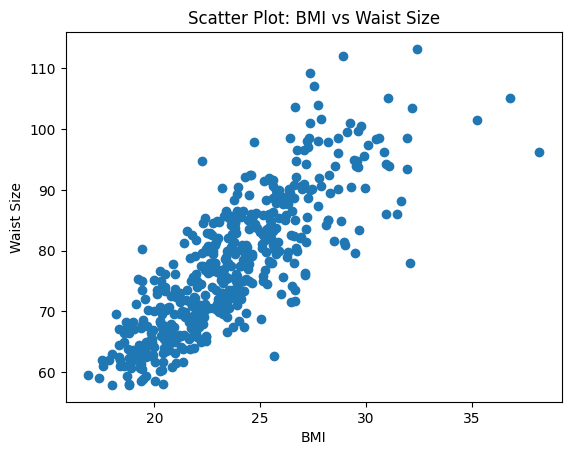

In [20]:
plt.scatter(df['bmi'], df['waist'])
plt.xlabel('BMI')
plt.ylabel('Waist Size')
plt.title('Scatter Plot: BMI vs Waist Size')
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

# เราจะใช้ Feature ทั้งหมด รวมถึง bmi ที่สร้างขึ้นใหม่ด้วย
X = df[['sex','age', 'weight', 'height', 'hip', 'bmi']]
y = df['waist']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}
grid_search = GridSearchCV(LinearRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_

# แสดงผลพารามิเตอร์ที่ดีที่สุด
print("Best parameters:", grid_search.best_params_)

Best parameters: {'fit_intercept': True, 'positive': False}


In [23]:
print("Coefficients (b1-b6):", model.coef_)
print("Intercept (b0):", model.intercept_)

Coefficients (b1-b6): [ 5.71196798  0.18463874  0.68910335 -0.30507417  0.14784985 -0.05621057]
Intercept (b0): 60.2606552411023


In [24]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 12.650484871447029
R-squared: 0.8709032612712897


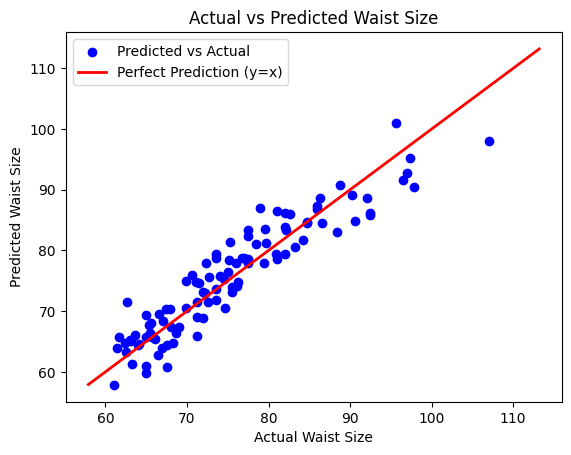

In [25]:
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, label='Perfect Prediction (y=x)')
plt.xlabel('Actual Waist Size')
plt.ylabel('Predicted Waist Size')
plt.title('Actual vs Predicted Waist Size')
plt.legend()
plt.show()

In [26]:
new_data = pd.DataFrame({
    'sex': [0, 1],
    'age': [25, 30],
    'weight': [70, 80],
    'height': [175, 180],
    'hip': [95, 100]
})

# คำนวณ BMI สำหรับข้อมูลใหม่
new_data['bmi'] = new_data['weight'] / (new_data['height']/100)**2

predicted_waist = model.predict(new_data)
print("Predicted Waist Sizes:", predicted_waist)

Predicted Waist Sizes: [72.48680086 85.12377217]


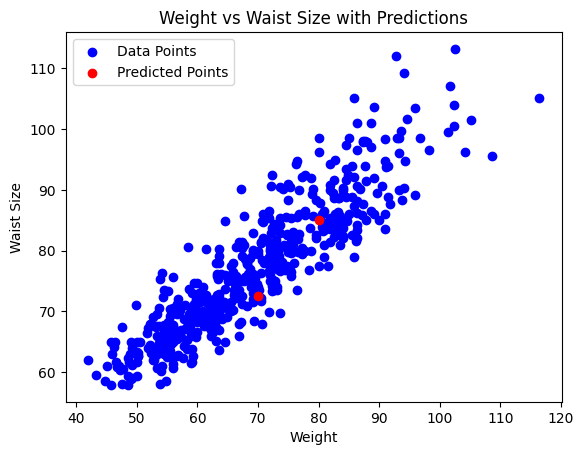

In [27]:
plt.scatter(df['weight'], df['waist'], color='blue', label='Data Points')
plt.scatter(new_data['weight'], predicted_waist, color='red', label='Predicted Points')
plt.xlabel('Weight')
plt.ylabel('Waist Size')
plt.title('Weight vs Waist Size with Predictions')
plt.legend()
plt.show()

In [28]:
import joblib

joblib.dump(model, 'waist_size_model.pkl')

['waist_size_model.pkl']

In [29]:
loaded_model = joblib.load('waist_size_model.pkl')

In [30]:
!pip install Flask pyngrok flask-cors

In [33]:
from flask import Flask, request, jsonify
from pyngrok import ngrok  # ใช้ pyngrok เพื่อเชื่อมต่อ ngrok
from flask_cors import CORS
import joblib
import pandas as pd

app = Flask(__name__)
CORS(app)

# ตั้งค่า ngrok authtoken
from google.colab import userdata

ngrok.set_auth_token(userdata.get('NGOK_AUTH_TOKEN'))  # ใส่ authtoken ที่คุณได้จาก ngrok

# เปิด ngrok tunnel ที่พอร์ต 5000 (พอร์ตที่ Flask ใช้งาน)
public_url = ngrok.connect(5000)
print(' * ngrok tunnel "http://127.0.0.1:5000" -> "http://127.0.0.1:5000"')
print(' * Public URL:', public_url)  # แสดง URL ของ ngrok

model = joblib.load('/content/waist_size_model.pkl')  # ใส่ path ที่ถูกต้องของไฟล์โมเดล

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()  # รับข้อมูลจาก POST request
    input_data = pd.DataFrame([data])  # แปลงข้อมูลเป็น DataFrame
    prediction = model.predict(input_data)  # ทำการทำนาย
    return jsonify({'predicted_waist': prediction[0]})  # คืนค่าผลการทำนาย

@app.route('/test', methods=['GET'])
def test():
    return jsonify({'result': 'success'})

if __name__ == '__main__':
    app.run()

 * ngrok tunnel "http://127.0.0.1:5000" -> "http://127.0.0.1:5000"
 * Public URL: NgrokTunnel: "https://loathsome-susurringly-sparkle.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [20/Oct/2025 04:16:07] "GET / HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [20/Oct/2025 04:17:14] "GET /test HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Oct/2025 04:30:12] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Oct/2025 04:40:42] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [20/Oct/2025 04:40:43] "POST /predict HTTP/1.1" 200 -
